# Analisis Sentimen & Word Cloud: Komentar YouTube "Rupiah Melemah"
**Summer Project - Analisis Data & Sentiment Analysis**

Notebook ini memuat seluruh alur kerja analisis data & sentimen langsung dari dataset Kaggle `dzikriraihan/indonesian-youtube-comments-rupiah-melemah`:
1. Memuat Data otomatis dari **Kaggle Hub** (`kagglehub`)
2. Pembersihan & Preprocessing Teks Bahasa Indonesia
3. Pelabelan Sentimen (Positif, Negatif, Netral)
4. Ringkasan & Visualisasi Distribusi Sentimen (Pie Chart & Bar Chart)
5. Visualisasi **Word Cloud** (Positif vs Negatif)

---

### 1. Import Library

In [7]:
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from wordcloud import WordCloud

plt.style.use('ggplot')
print('Library berhasil dimuat!')

Library berhasil dimuat!


### 2. Memuat Dataset Langsung dari Kaggle

In [3]:
# Download / Load dataset dari Kaggle secara otomatis
try:
    print("Memuat dataset dari Kagglehub...")
    path = kagglehub.dataset_download("dzikriraihan/indonesian-youtube-comments-rupiah-melemah")
    csv_path = os.path.join(path, "Comment Youtube Rupiah melemah.csv")
    df = pd.read_csv(csv_path)
    print(f"Berhasil memuat dataset dari Kaggle! Total data: {len(df)}")
except Exception as e:
    print(f"Gagal memuat dari Kaggle, menggunakan file lokal: {e}")
    df = pd.read_csv('rupiah_melemah_comments.csv')

df.head()

Memuat dataset dari Kagglehub...
Berhasil memuat dataset dari Kaggle! Total data: 17840


,Video ID,Comment ID,Comment Link,Commenter Name,Commenter ID,Comment,Likes
0,sB7fSPbYFJg,UgycdW9c-JHCjxy6sTB4AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@ArkanUkail-s1b,UCl5ayjbjB7U0FnkO9MvjgIA,Loh bukannya kejadian ini terjadinya di tahun ...,0
1,sB7fSPbYFJg,UgxRD2BGMzVJX4jxtTN4AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@balldestroyer16,UCiYr_VCB_bRYMxX-QPqJ8OA,Damn kok kebetulan banget yah?,0
2,sB7fSPbYFJg,UgyDw5owDtUJC3yWrWd4AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@AUFAL_RIVALS,UCMvlFGGxhxqSQ5nOia4z7jg,ku kira baru upload 🗿,0
3,sB7fSPbYFJg,UgwMIdFZwH2xIi7I0G14AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@ddoddo5,UCanS1fV2JP98gBgOssTgdqA,algoritmanya bisa pas banget gini ya haha,0
4,sB7fSPbYFJg,UgzfJiQq4c9hiROxffF4AaABAg,https://www.youtube.com/watch?v=sB7fSPbYFJg&lc...,@RaniaXiaomi,UCjxCe7IgEItMvuSzABGh1jA,apakah ini cmn kebetulan lewat doang?,0


### 3. Pembersihan Teks & Pelabelan Sentimen

In [4]:
# Kamus kata sentimen Bahasa Indonesia
POSITIVE_WORDS = set([
    'menguat', 'bagus', 'mantap', 'aman', 'hebat', 'dukung', 'percaya', 'optimis', 'baik', 'setuju',
    'senang', 'untung', 'stabil', 'maju', 'juara', 'semangat', 'positif', 'berhasil', 'sukses',
    'solusi', 'bangga', 'keren', 'paham', 'bijak', 'rezeki', 'berkah', 'semoga', 'amiin', 'amin'
])

NEGATIVE_WORDS = set([
    'melemah', 'hancur', 'korupsi', 'bohong', 'miskin', 'parah', 'rusak', 'rugi', 'anjlok', 'gagal',
    'becus', 'ngeles', 'bacot', 'nyocot', 'drama', 'ancam', 'beban', 'turun', 'bencana', 'utang',
    'stres', 'kasihan', 'kelaparan', 'benci', 'goblok', 'tolol', 'bodoh', 'sengsara', 'krisis'
])

SLANG_MAP = {
    'yg': 'yang', 'ga': 'tidak', 'gak': 'tidak', 'nggak': 'tidak', 'dgn': 'dengan',
    'sdh': 'sudah', 'udh': 'sudah', 'sy': 'saya', 'skrg': 'sekarang', 'utk': 'untuk',
    'bgt': 'banget', 'tp': 'tapi', 'sm': 'sama', 'dr': 'dari', 'klo': 'kalau',
    'kl': 'kalau', 'lg': 'lagi', 'trs': 'terus', 'jd': 'jadi', 'aja': 'saja'
}

NEGATION_WORDS = set(['tidak', 'bukan', 'jangan', 'tanpa', 'kurang'])

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&[a-z0-9]+;', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    words = [SLANG_MAP.get(w, w) for w in text.split()]
    return " ".join(words)

def get_sentiment(text):
    cleaned = clean_text(text)
    words = cleaned.split()
    pos_score, neg_score = 0, 0
    for i, word in enumerate(words):
        is_negated = i > 0 and words[i-1] in NEGATION_WORDS
        if word in POSITIVE_WORDS:
            if is_negated:
                neg_score += 1
            else:
                pos_score += 1
        elif word in NEGATIVE_WORDS:
            if is_negated:
                pos_score += 1
            else:
                neg_score += 1
    net = pos_score - neg_score
    label = 'Positif' if net > 0 else ('Negatif' if net < 0 else 'Netral')
    return pd.Series([cleaned, label], index=['Cleaned_Comment', 'Sentiment'])

print('Memproses pembersihan & sentimen...')
df[['Cleaned_Comment', 'Sentiment']] = df['Comment'].apply(get_sentiment)
print('Proses analisis selesai!')

Memproses pembersihan & sentimen...
Proses analisis selesai!


### 4. Ringkasan Hasil Sentimen

In [5]:
summary_df = pd.DataFrame({
    'Jumlah': df['Sentiment'].value_counts(),
    'Persentase (%)': (df['Sentiment'].value_counts(normalize=True) * 100).round(2)
})
summary_df

,Jumlah,Persentase (%)
Sentiment,,
Netral,13246,74.25
Positif,2358,13.22
Negatif,2236,12.53


### 5. Visualisasi Grafik Distribusi Sentimen

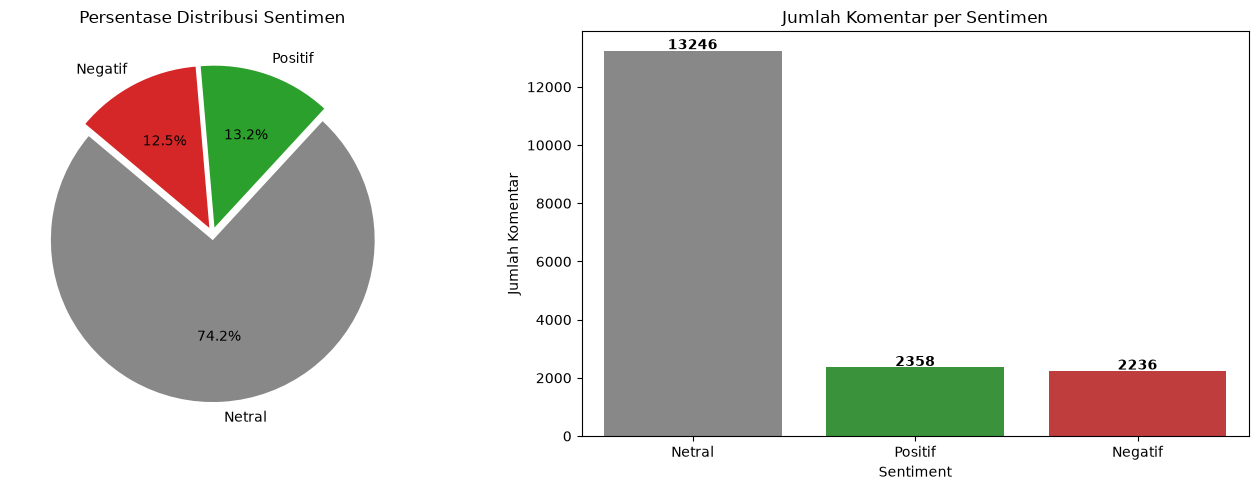

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
counts = df['Sentiment'].value_counts()
colors = ['#888888', '#2ca02c', '#d62728']

# Pie Chart
axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.04, 0.04, 0.04))
axes[0].set_title('Persentase Distribusi Sentimen')

# Bar Chart
sns.barplot(x=counts.index, y=counts.values, ax=axes[1], hue=counts.index, palette=colors, legend=False)
axes[1].set_title('Jumlah Komentar per Sentimen')
axes[1].set_ylabel('Jumlah Komentar')
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 6. Visualisasi Word Cloud (Positif vs Negatif)

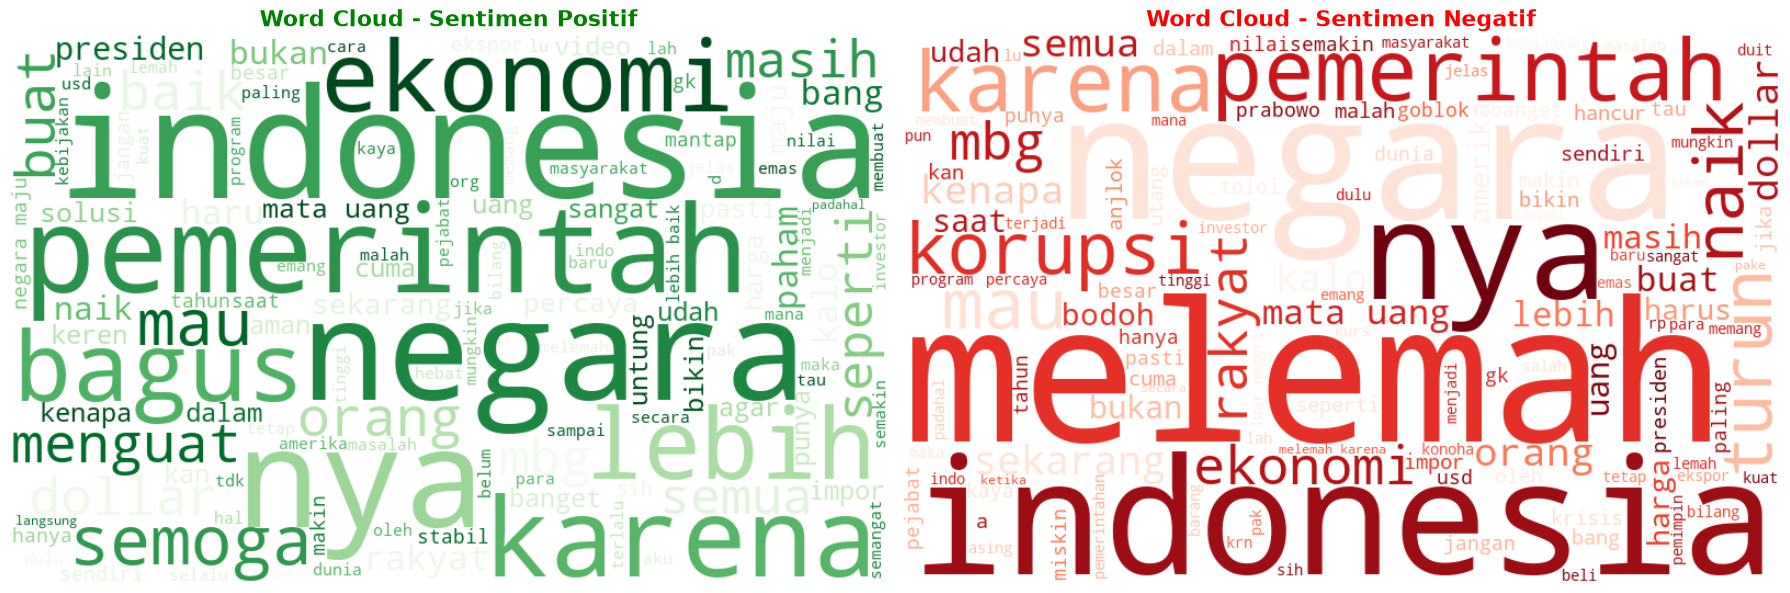

In [8]:
stopwords = set([
    'yang', 'di', 'ke', 'dari', 'ini', 'itu', 'dengan', 'untuk', 'pada', 'adalah', 'sebagai',
    'dan', 'atau', 'juga', 'akan', 'bisa', 'sudah', 'saya', 'kita', 'kami', 'mereka', 'dia',
    'ada', 'tidak', 'tapi', 'kalau', 'lagi', 'terus', 'jadi', 'saja', 'ya', 'gak', 'udh', 'yg',
    'sama', 'banyak', 'karna', 'apa', 'biar', 'gimana', 'kok', 'dengn', 'gua', 'gw', 'dolar', 'rupiah'
])

pos_text = ' '.join(df[df['Sentiment'] == 'Positif']['Cleaned_Comment'].dropna())
neg_text = ' '.join(df[df['Sentiment'] == 'Negatif']['Cleaned_Comment'].dropna())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Word Cloud Positif
wc_pos = WordCloud(width=800, height=500, background_color='white', colormap='Greens', stopwords=stopwords, max_words=120).generate(pos_text)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud - Sentimen Positif', fontsize=16, fontweight='bold', color='green')

# Word Cloud Negatif
wc_neg = WordCloud(width=800, height=500, background_color='white', colormap='Reds', stopwords=stopwords, max_words=120).generate(neg_text)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud - Sentimen Negatif', fontsize=16, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

### 7. Simpan Hasil Analisis ke CSV Lokal

In [9]:
output_file = 'rupiah_melemah_sentiment_results.csv'
df.to_csv(output_file, index=False, encoding='utf-8-sig')
print(f'Hasil berhasil disimpan ke: {output_file}')

Hasil berhasil disimpan ke: rupiah_melemah_sentiment_results.csv
